In [1]:
from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
import mdtraj as md

In [2]:
def add_ordinal_suffix(n):
    """
    Add the appropriate ordinal suffix ('st', 'nd', 'rd', 'th') to an integer.

    Args:
        n (int): The integer to which the ordinal suffix should be added.

    Returns:
        str: The integer as a string with the appropriate ordinal suffix.
    """
    # Handle special cases for 11, 12, 13
    if 10 <= n % 100 <= 13:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    
    return f"{n}{suffix}"

In [3]:
def dir_to_trj(path, calpha_only=False):
    
    pdb_list = glob(path + '/*.pdb')
    print('found %d hit pdbs' % len(pdb_list))

    structures = None
    cells = []
    
    for pdb in tqdm(pdb_list):

        try:

            trj = md.load_pdb(pdb)
            if calpha_only:
                idx = trj.top.select('(type != H) and is_protein and (name == CA)')
            else:
                idx = trj.top.select('(type != H) and is_protein')
            trj = trj.atom_slice(idx)

            if structures:
                structures = structures.join(trj)
            else:
                structures = trj

        except Exception as e:
            print(pdb, e)
            print(trj.n_atoms, structures.n_atoms)

    structures = structures.center_coordinates()
    print('final num loaded:', len(structures))

    return structures

In [4]:
SELECTED_DATASET_PDBS = '/gpfs/cfel/user/tjlane/mpro/allostery/selected_dataset_archive_2024-08-07/pdb'

apo_calpha = dir_to_trj(SELECTED_DATASET_PDBS, calpha_only=True)
apo_all = dir_to_trj(SELECTED_DATASET_PDBS, calpha_only=False)

  0%|          | 0/1146 [00:00<?, ?it/s]

found 1146 hit pdbs


  0%|          | 1/1146 [00:00<03:14,  5.88it/s]

final num loaded: 1146
found 1146 hit pdbs


100%|██████████| 1146/1146 [04:21<00:00,  4.38it/s]

final num loaded: 1146


In [5]:
def all_to_all_rmsd(trj):
    result = []
    for j in range(trj.n_frames):
        rmsds = md.rmsd(trj, trj[j], precentered=False) * 10.0
        result.extend(rmsds)
    return np.array(result)


def xyz_average_atomic_deviation(trajectory):
    mean_structure = trajectory[0]
    mean_structure.xyz[0] = trajectory.xyz.mean(axis=0)

    per_xyz_std = np.std(trajectory.xyz * 10.0, axis=0)  # mdtraj uses nm
    average_std = np.mean(per_xyz_std, axis=1)

    return average_std

In [7]:
calpha_average_std = xyz_average_atomic_deviation(apo_calpha)
calpha_all_to_all_rmsd = all_to_all_rmsd(apo_calpha)

all_atom_average_std = xyz_average_atomic_deviation(apo_all)
all_atom_all_to_all_rmsd = all_to_all_rmsd(apo_all)

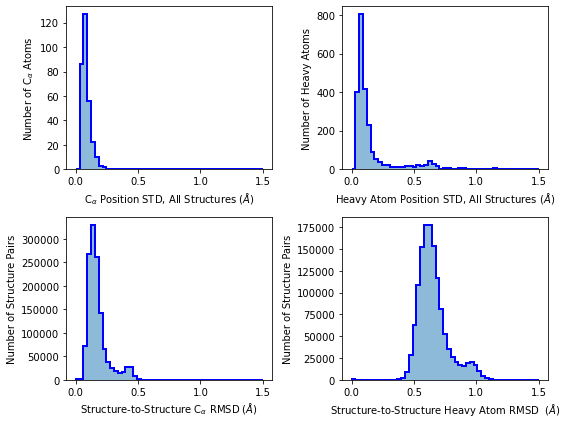

In [23]:
bins = np.linspace(0.0, 1.5, 50)

plt.figure(figsize=(8,6))

plt.subplot(221)
plt.hist(calpha_average_std, alpha=0.5, lw=2, bins=bins)
plt.hist(calpha_average_std, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"C$_\alpha$ Position STD, All Structures ($\AA$)")
plt.ylabel(r"Number of C$_\alpha$ Atoms")

plt.subplot(222)
plt.hist(all_atom_average_std, alpha=0.5, lw=2, bins=bins)
plt.hist(all_atom_average_std, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"Heavy Atom Position STD, All Structures ($\AA$)")
plt.ylabel(r"Number of Heavy Atoms")

plt.subplot(223)
plt.hist(calpha_all_to_all_rmsd, alpha=0.5, lw=2, bins=bins)
plt.hist(calpha_all_to_all_rmsd, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"Structure-to-Structure C$_\alpha$ RMSD ($\AA$)")
plt.ylabel(r"Number of Structure Pairs")

plt.subplot(224)
plt.hist(all_atom_all_to_all_rmsd, alpha=0.5, lw=2, bins=bins)
plt.hist(all_atom_all_to_all_rmsd, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"Structure-to-Structure Heavy Atom RMSD  ($\AA$)")
plt.ylabel(r"Number of Structure Pairs")

plt.tight_layout()
plt.savefig("./displacement_summary.png")
plt.show()

## now same thing for DESRES MD

In [10]:
def load_simulation(glob_pattern, top_path, subsampling=1, atom_selection='(element != H) and is_protein', Ca_only=True):

    md_files = sorted(glob(glob_pattern))
    print(f"found {len(md_files)} trajectory files...")
    
    md_sim = None

    for f in tqdm(md_files):
    
        t = md.load(f, top=top_path)[::subsampling]
    
        idx = t.top.select(atom_selection)
        t   = t.atom_slice(idx)

        if Ca_only:
            idx = t.top.select('name == CA')
            t   = t.atom_slice(idx)
    
        if md_sim == None:
            md_sim = t
        else:
            md_sim += t
    
    md_sim = md_sim.center_coordinates()
    
    return md_sim

In [15]:
# DESRES
# sampling is 1 ns, so subsampled 1/1 is 1 ns

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
glob_pattern = prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'
top_path = prefix + '/system_nowat.pdb'

desres_sim = load_simulation(glob_pattern, top_path, subsampling=100, Ca_only=False)
desres_sim_ca = desres_sim.atom_slice(desres_sim.top.select('name == CA'))

In [17]:
desres_calpha_average_std = xyz_average_atomic_deviation(desres_sim_ca)
desres_calpha_all_to_all_rmsd = all_to_all_rmsd(desres_sim_ca)

desres_all_atom_average_std = xyz_average_atomic_deviation(desres_sim)
desres_all_atom_all_to_all_rmsd = all_to_all_rmsd(desres_sim)

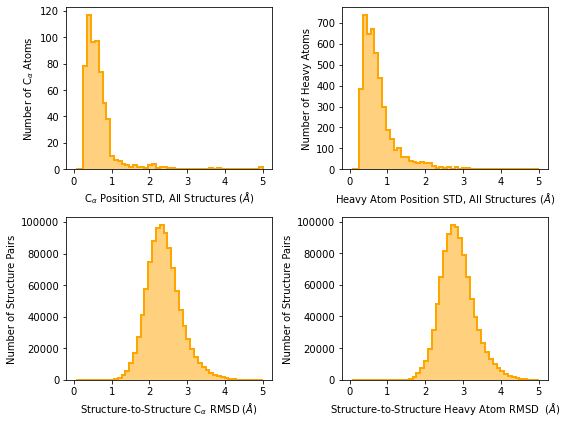

In [22]:
desres_color = "orange"
bins = np.linspace(0.05, 5.0, 50)

plt.figure(figsize=(8,6))

plt.subplot(221)
plt.hist(desres_calpha_average_std, alpha=0.5, lw=2, color=desres_color, bins=bins)
plt.hist(desres_calpha_average_std, histtype='step', lw=2, color=desres_color, bins=bins)
plt.xlabel(r"C$_\alpha$ Position STD, All Structures ($\AA$)")
plt.ylabel(r"Number of C$_\alpha$ Atoms")

plt.subplot(222)
plt.hist(desres_all_atom_average_std, alpha=0.5, lw=2, color=desres_color, bins=bins)
plt.hist(desres_all_atom_average_std, histtype='step', lw=2, color=desres_color, bins=bins)
plt.xlabel(r"Heavy Atom Position STD, All Structures ($\AA$)")
plt.ylabel(r"Number of Heavy Atoms")

plt.subplot(223)
plt.hist(desres_calpha_all_to_all_rmsd, alpha=0.5, lw=2, color=desres_color, bins=bins)
plt.hist(desres_calpha_all_to_all_rmsd, histtype='step', lw=2, color=desres_color, bins=bins)
plt.xlabel(r"Structure-to-Structure C$_\alpha$ RMSD ($\AA$)")
plt.ylabel(r"Number of Structure Pairs")

plt.subplot(224)
plt.hist(desres_all_atom_all_to_all_rmsd, alpha=0.5, lw=2, color=desres_color, bins=bins)
plt.hist(desres_all_atom_all_to_all_rmsd, histtype='step', lw=2, color=desres_color, bins=bins)
plt.xlabel(r"Structure-to-Structure Heavy Atom RMSD  ($\AA$)")
plt.ylabel(r"Number of Structure Pairs")

plt.tight_layout()
plt.savefig("./displacement_summary_DESRES-MD.png")
plt.show()